# ARC free-parameter scan: solved electron pressure profiles

Plots every ESCAPE $p_e = n_e T_e$ profile from the free-parameter scan run by
`scan_SCfp_ESCAPE.py` (submitted with `scan_SCfp_ESCAPE.slurm`), against the
digitized ARC input profiles.

The scan writes one directory per combination, `fp<i>`, where `i` indexes the
`itertools.product` over `alpha_crit`, `C_KBM`, `De_chie_etg`, `nFC_x0` and
`ncx_x0_ratio`. Successful runs contain `out_dict.npy`; failures contain
`failed.npy` instead, so globbing for `out_dict.npy` selects exactly the
combinations that worked. The scan may still be running - this notebook plots
whatever has finished so far, so re-run it to pick up new solutions.

`out_dict` stores only the raw solver output, so $p_e$ is reconstructed below
from `profiles_solved` ($n_e$ in m$^{-3}$, $T_e$ in eV) and the input $p_e$ from
the saved `manual_profs`. Unlike the SPARC scan, the ARC run uses
`kprof_loc = 'manual profs'`, so the inputs are already on $\psi_N$ grids
(`psi_N_ne`, `psi_N_Te`) with $n_e$ in m$^{-3}$ and $T_e$ in keV - no
$\rho_\psi = \sqrt{\psi_N}$ conversion is needed.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize

SCAN_DIR = Path('ARC_workflow_noKBM_ETG05')

# Colour each solved profile by one free parameter. Set to None for a single colour.
COLOR_BY = 'alpha_crit'   # 'alpha_crit' | 'C_KBM' | 'De_chie_etg' | 'nFC_x0' | 'ncx_x0_ratio' | None
LOG_COLOR = True          # log colour scale, right for alpha_crit and nFC_x0 (both logspaced in the scan)

e_C = 1.602176634e-19  # J/eV

In [2]:
# p_e reconstruction. The ARC out_dict stores the solver output directly
# rather than pre-computed pressure curves, so build them here.

def electron_pressure(psi_ne, ne_m3, psi_Te, Te_eV):
    """p_e [Pa] on the density grid, with T_e interpolated onto it."""
    psi_Te, Te_eV = np.asarray(psi_Te, float), np.asarray(Te_eV, float)
    o = np.argsort(psi_Te)
    return np.interp(psi_ne, psi_Te[o], Te_eV[o]) * np.asarray(ne_m3, float) * e_C


def escape_pe(d):
    """ESCAPE (psi_N, p_e [Pa]) on an ascending grid.

    profiles_solved: 'y' is n_e [m^-3] on 'psi_N_ne', 'T_e' is in eV on 'psi_N'.
    """
    s = d['profiles_solved']
    psi = np.asarray(s['psi_N_ne'], float)
    o = np.argsort(psi)
    psi = psi[o]
    return psi, electron_pressure(psi, np.asarray(s['y'], float)[o],
                                  s['psi_N'], s['T_e'])


def input_pe(d):
    """Input (digitized ARC) (psi_N, p_e [Pa]) from the saved manual_profs.

    manual_profs for kprof_loc = 'manual profs': 'ne' [m^-3] on 'psi_N_ne' and
    'Te' [keV] on 'psi_N_Te', both already in psi_N (no rho_psi conversion).
    """
    p = d['profiles']
    psi_ne = np.asarray(p['psi_N_ne'], float)
    psi_Te = np.asarray(p['psi_N_Te'], float)
    ne = np.asarray(p['ne'], float)
    Te_eV = np.asarray(p['Te'], float) * 1e3
    o = np.argsort(psi_ne)
    return psi_ne[o], electron_pressure(psi_ne[o], ne[o], psi_Te, Te_eV)


def zoom_y(ax, x_lo, x_hi=1.0, pad=0.05):
    """Autoscale y over only the data inside [x_lo, x_hi].

    The input profiles run all the way to the magnetic axis, where p_e is an
    order of magnitude above the pedestal, so plain autoscaling would flatten
    the region of interest.
    """
    top = 0.0
    for ln in ax.get_lines():
        x = np.asarray(ln.get_xdata(), float)
        y = np.asarray(ln.get_ydata(), float)
        m = (x >= x_lo) & (x <= x_hi) & np.isfinite(y)
        if m.any():
            top = max(top, float(np.max(y[m])))
    if top > 0:
        ax.set_ylim(0, top * (1 + pad))

In [3]:
# Load every completed scan point. Directories are fp<i>, i indexing the
# itertools.product over the five free parameters.
def _dir_key(p):
    return int(p.parent.name.removeprefix('fp'))

runs = []
for fp in sorted(SCAN_DIR.glob('fp*/out_dict.npy'), key=_dir_key):
    d = np.load(fp, allow_pickle=True).item()
    if d.get('failed'):
        continue
    d['esc_psi'], d['esc_pe'] = escape_pe(d)
    runs.append(d)

n_failed = len(list(SCAN_DIR.glob('fp*/failed.npy')))
n_dirs = len(list(SCAN_DIR.glob('fp*')))

# The scan grid in scan_SCfp_ESCAPE.py: 3 * 3 * 3 * 4 * 4
SCAN_TOTAL = 3 * 3 * 3 * 4 * 4

if not runs:
    raise RuntimeError(f'No completed runs with out_dict.npy found under {SCAN_DIR}')

print(f'{len(runs)} solved, {n_failed} failed, {n_dirs} of {SCAN_TOTAL} scan directories present')
print(f'free parameters: {list(runs[0]["free_params"])}')

17 solved, 8 failed, 25 of 432 scan directories present
free parameters: ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0', 'ncx_x0_ratio']


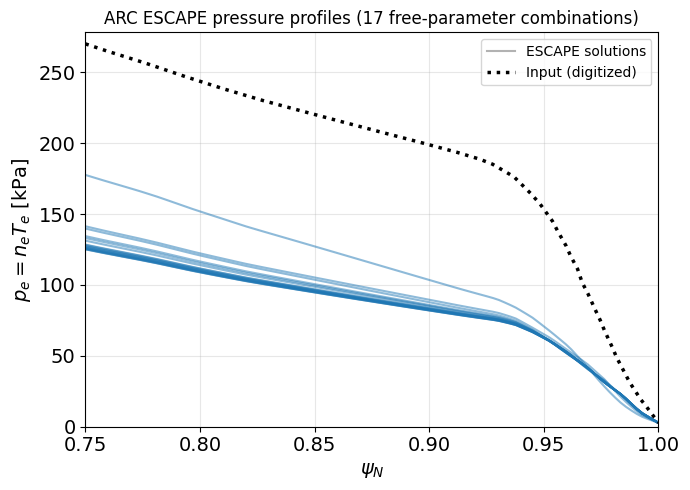

In [4]:
# The input profile is identical for every run
psi_in, pe_in = input_pe(runs[0])

# Colour mapping over the chosen free parameter. Early in the scan the outer
# loop parameters have not advanced yet, so every run can share one value - fall
# back to a single colour rather than build a degenerate norm.
vals = None
colors = ['C0'] * len(runs)
if COLOR_BY is not None:
    vals = np.array([float(r['free_params'][COLOR_BY]) for r in runs])
    if vals.min() != vals.max():
        norm = (LogNorm(vals.min(), vals.max()) if LOG_COLOR and vals.min() > 0
                else Normalize(vals.min(), vals.max()))
        cmap = plt.get_cmap('viridis')
        colors = [cmap(norm(v)) for v in vals]

fig, ax = plt.subplots(figsize=(7, 5))

for r, c in zip(runs, colors):
    # ax.plot(np.asarray(r['esc_psi'], float), np.asarray(r['esc_pe'], float) / 1e3,
    #         '-', lw=1.5, color=c, alpha=0.5)
    ax.plot(np.asarray(r['esc_psi'], float), np.asarray(r['esc_pe'], float) / 1e3,
            '-', lw=1.5, color='tab:blue', alpha=0.5)

ax.plot(psi_in, pe_in / 1e3, 'k:', lw=2.5, label='Input (digitized)', zorder=10)

# Zoom on the pedestal region the solutions actually cover
psi_min = min(float(np.min(r['esc_psi'])) for r in runs)
ax.set_xlim(psi_min, 1.0)
zoom_y(ax, psi_min)
ax.set_xlabel(r'$\psi_N$', fontsize=14)
ax.set_ylabel(r'$p_e = n_e T_e$ [kPa]', fontsize=14)
ax.set_title(f'ARC ESCAPE pressure profiles ({len(runs)} free-parameter combinations)')
ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=14)

handles = [plt.Line2D([], [], color='0.4', lw=1.5, alpha=0.5, label='ESCAPE solutions')]
handles += ax.get_legend_handles_labels()[0]
ax.legend(handles=handles, loc='upper right', fontsize=10)

# if vals is not None and vals.min() != vals.max():
#     sm = ScalarMappable(norm=norm, cmap=cmap)
#     sm.set_array([])
#     fig.colorbar(sm, ax=ax, label=COLOR_BY)

fig.tight_layout()
plt.show()

In [5]:
# Spread of the solved profiles at the inner edge of the solved region
pe_top = np.array([np.interp(psi_min, np.asarray(r['esc_psi'], float),
                             np.asarray(r['esc_pe'], float)) for r in runs])
pe_in_at = float(np.interp(psi_min, psi_in, pe_in))

print(f'p_e at psi_N = {psi_min:.3f}')
print(f'  input (digitized) : {pe_in_at/1e3:8.3f} kPa')
print(f'  ESCAPE min        : {pe_top.min()/1e3:8.3f} kPa')
print(f'  ESCAPE median     : {np.median(pe_top)/1e3:8.3f} kPa')
print(f'  ESCAPE max        : {pe_top.max()/1e3:8.3f} kPa')

p_e at psi_N = 0.750
  input (digitized) :  270.075 kPa
  ESCAPE min        :  126.289 kPa
  ESCAPE median     :  130.397 kPa
  ESCAPE max        :  168.683 kPa


## Separatrix density free parameters

The separatrix density is set by the two neutral-density free parameters,

$$n_{sep} = n_{FC}(0) + n_{FC}(0)\cdot\frac{n_{CX}(0)}{n_{FC}(0)} = n_{FC}(0)\,\left(1 + \frac{n_{CX}(0)}{n_{FC}(0)}\right)$$

The plots below hold `alpha_crit`, `C_KBM` and `De_chie_etg` fixed and vary only
`nFC_x0` and `ncx_x0_ratio`: first every combination of the two, then each one
separately with the other also held fixed.

In [6]:
from collections import Counter

# Number of (nFC_x0, ncx_x0_ratio) combinations per fixed slice, from the scan grid
N_DENSITY_COMBOS = 4 * 4

# Parameters held fixed while the two density parameters vary.
# Leave a value as None to auto-pick the slice with the most completed runs;
# set it explicitly (e.g. 'De_chie_etg': 0.55) to pin a particular slice.
FIXED = {'alpha_crit': None, 'C_KBM': None, 'De_chie_etg': None}

def par(r, k):
    return float(r['free_params'][k])

def n_sep(r):
    """Separatrix density: nFC(0) + nFC(0) * nCX(0)/nFC(0)."""
    return par(r, 'nFC_x0') * (1.0 + par(r, 'ncx_x0_ratio'))

def select(pool, **constraints):
    """Runs whose free parameters match every non-None constraint."""
    return [r for r in pool
            if all(np.isclose(par(r, k), float(v))
                   for k, v in constraints.items() if v is not None)]

# Resolve any unset fixed value to the combination with the most solved runs,
# so the selection is non-empty while the scan is still filling in.
if any(v is None for v in FIXED.values()):
    counts = Counter(tuple(par(r, k) for k in FIXED) for r in runs)
    best = counts.most_common(1)[0][0]
    FIXED = {k: (v if v is not None else b)
             for (k, v), b in zip(FIXED.items(), best)}

density_runs = select(runs, **FIXED)
if not density_runs:
    raise RuntimeError(f'No solved runs match FIXED = {FIXED}')

print('Holding fixed: ' + ',  '.join(f'{k} = {v:.4g}' for k, v in FIXED.items()))
print(f'{len(density_runs)} of {N_DENSITY_COMBOS} density combinations solved in this slice')
print(f'  nFC_x0       : {np.unique([par(r, "nFC_x0") for r in density_runs])}')
print(f'  ncx_x0_ratio : {np.unique([par(r, "ncx_x0_ratio") for r in density_runs])}')

Holding fixed: alpha_crit = 0.1,  C_KBM = 0,  De_chie_etg = 0.3162
10 of 16 density combinations solved in this slice
  nFC_x0       : [3.16227766e+14 3.16227766e+15 3.16227766e+16]
  ncx_x0_ratio : [ 0.1  1.  10.  20. ]


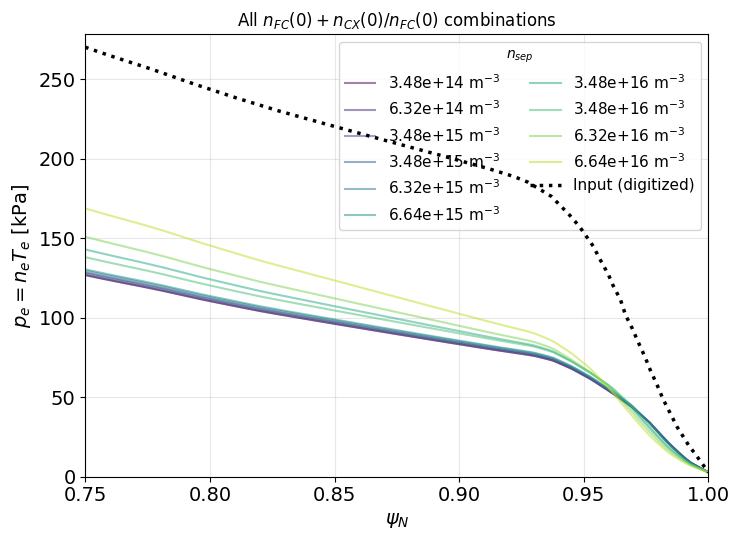

In [7]:
def plot_profiles(ax, group, label_fn, sort_fn, title, legend_title=None, ncol=1):
    """Plot p_e for a group of runs, coloured and legended by one quantity."""
    group = sorted(group, key=sort_fn)
    cols = plt.get_cmap('viridis')(np.linspace(0, 0.9, max(len(group), 1)))

    for r, c in zip(group, cols):
        ax.plot(np.asarray(r['esc_psi'], float), np.asarray(r['esc_pe'], float) / 1e3,
                '-', lw=1.5, color=c, alpha=0.5, label=label_fn(r))

    ax.plot(psi_in, pe_in / 1e3, 'k:', lw=2.5, label='Input (digitized)', zorder=10)

    lo = min(float(np.min(r['esc_psi'])) for r in group)
    ax.set_xlim(lo, 1.0)
    zoom_y(ax, lo)
    ax.set_xlabel(r'$\psi_N$', fontsize=14)
    ax.set_ylabel(r'$p_e = n_e T_e$ [kPa]', fontsize=14)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=11, loc='upper right', title=legend_title, ncol=ncol)


# Every combination of nFC(0) and nCX(0)/nFC(0), legended by separatrix density
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_profiles(
    ax, density_runs,
    label_fn=lambda r: rf'{n_sep(r):.2e} m$^{{-3}}$',
    sort_fn=n_sep,
    title=(rf'All $n_{{FC}}(0) + n_{{CX}}(0)/n_{{FC}}(0)$ combinations '),
    legend_title=r'$n_{sep}$', ncol=2,
)
fig.tight_layout()
plt.show()

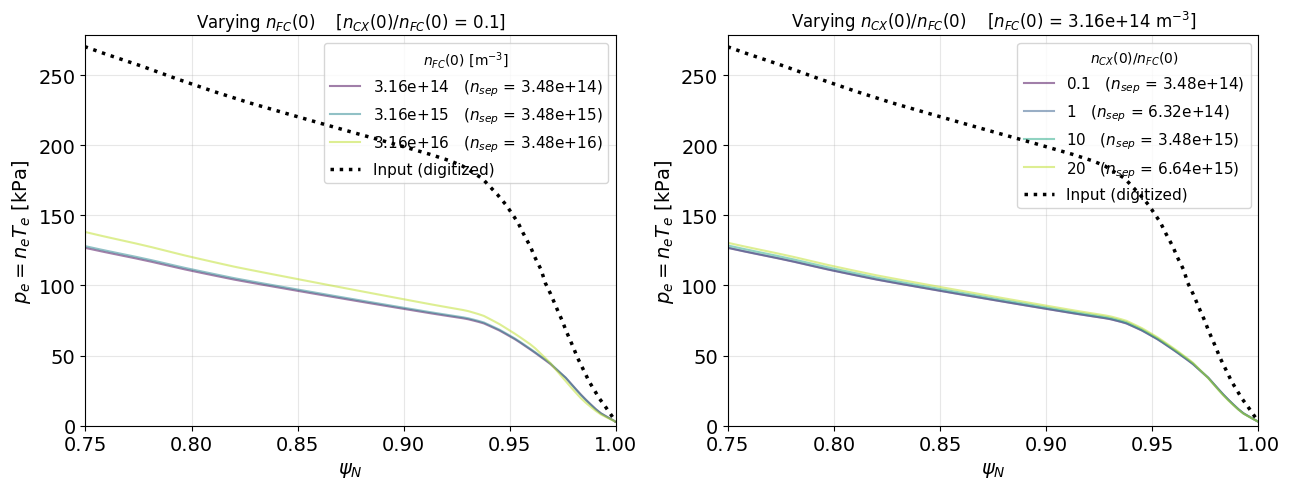

vary nFC(0):            3 runs
vary nCX(0)/nFC(0):     4 runs


In [8]:
# Each density parameter separately, with the other one also held fixed.
# Set either to a specific grid value to pin it; None auto-picks the value with
# the most solved runs in this slice.
NCX_RATIO_FIXED = None   # for the "vary nFC(0)" panel
NFC_X0_FIXED = None      # for the "vary nCX(0)/nFC(0)" panel

if NCX_RATIO_FIXED is None:
    NCX_RATIO_FIXED = Counter(par(r, 'ncx_x0_ratio') for r in density_runs).most_common(1)[0][0]
if NFC_X0_FIXED is None:
    NFC_X0_FIXED = Counter(par(r, 'nFC_x0') for r in density_runs).most_common(1)[0][0]

vary_nFC = select(density_runs, ncx_x0_ratio=NCX_RATIO_FIXED)
vary_ncx = select(density_runs, nFC_x0=NFC_X0_FIXED)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_profiles(
    axes[0], vary_nFC,
    label_fn=lambda r: rf'{par(r, "nFC_x0"):.2e}   ($n_{{sep}}$ = {n_sep(r):.2e})',
    sort_fn=lambda r: par(r, 'nFC_x0'),
    title=(rf'Varying $n_{{FC}}(0)$    '
           rf'[$n_{{CX}}(0)/n_{{FC}}(0)$ = {NCX_RATIO_FIXED:.4g}]'),
    legend_title=r'$n_{FC}(0)$ [m$^{-3}$]',
)

plot_profiles(
    axes[1], vary_ncx,
    label_fn=lambda r: rf'{par(r, "ncx_x0_ratio"):.4g}   ($n_{{sep}}$ = {n_sep(r):.2e})',
    sort_fn=lambda r: par(r, 'ncx_x0_ratio'),
    title=(rf'Varying $n_{{CX}}(0)/n_{{FC}}(0)$    '
           rf'[$n_{{FC}}(0)$ = {NFC_X0_FIXED:.2e} m$^{{-3}}$]'),
    legend_title=r'$n_{CX}(0)/n_{FC}(0)$',
)

fig.tight_layout()
plt.show()

print(f'vary nFC(0):            {len(vary_nFC)} runs')
print(f'vary nCX(0)/nFC(0):     {len(vary_ncx)} runs')

## Solved $T_e$ and $n_e$ profiles

The same density-parameter family as above, but showing the two profiles that
build the pressure separately. The input curves come from the `manual_profs`
dict recorded in `out_dict['profiles']` - the digitized ARC $n_e$ / $T_e$ of
`ARC_ne.csv` and `ARC_Te.csv` (the scan stores the profiles themselves rather
than a file path, so nothing needs re-reading from disk).

Note the solver returns these on different grids: $T_e$ spans the full
$\psi_N$ range in eV, while $n_e$ is given in m$^{-3}$ on the pedestal solve
region only, and its $\psi_N$ grid comes back unsorted.

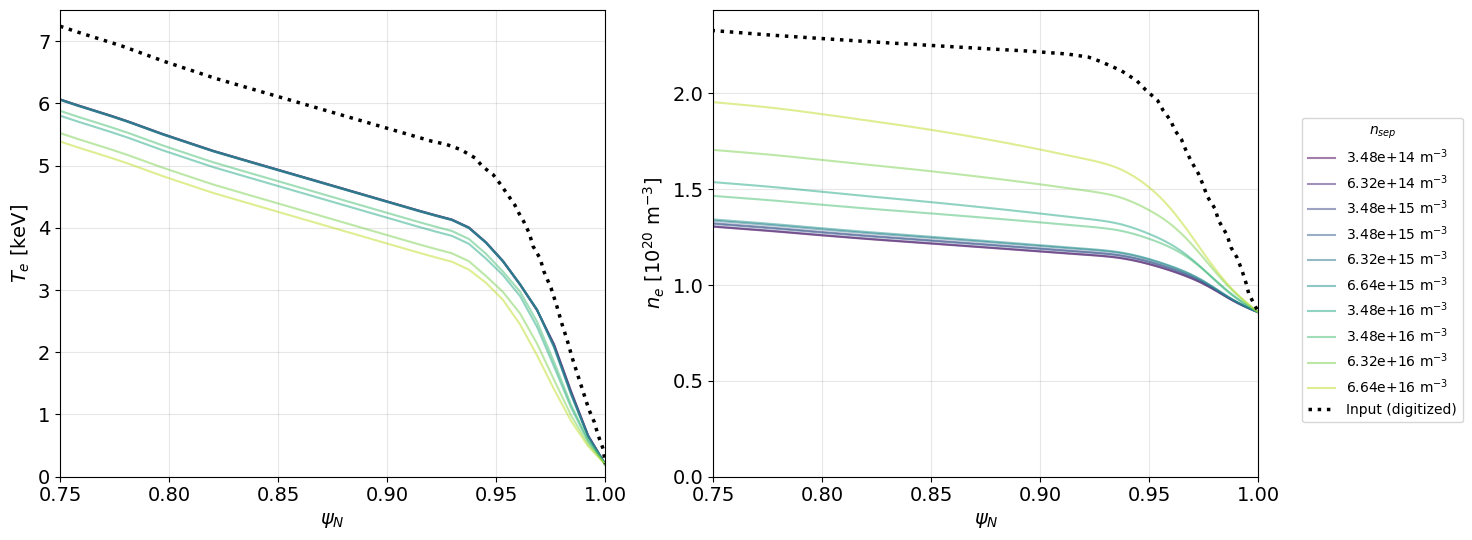

In [10]:
def input_profiles(d):
    """Input T_e [keV] and n_e [10^20 m^-3] on psi_N, from manual_profs.

    manual_profs stores n_e in m^-3; rescale for plotting.
    """
    p = d['profiles']
    return {
        'Te_psi': np.asarray(p['psi_N_Te'], float), 'Te': np.asarray(p['Te'], float),
        'ne_psi': np.asarray(p['psi_N_ne'], float), 'ne': np.asarray(p['ne'], float) / 1e20,
    }

pf = input_profiles(runs[0])


def solved_Te(r):
    """ESCAPE T_e [keV] on its own psi_N grid."""
    s = r['profiles_solved']
    return np.asarray(s['psi_N'], float), np.asarray(s['T_e'], float) / 1e3

def solved_ne(r):
    """ESCAPE n_e [10^20 m^-3], sorted onto an ascending psi_N grid."""
    s = r['profiles_solved']
    psi = np.asarray(s['psi_N_ne'], float)
    o = np.argsort(psi)
    return psi[o], np.asarray(s['y'], float)[o] / 1e20


def plot_quantity(ax, group, getter, ref_x, ref_y, ylabel, title,
                  legend_title=r'$n_{sep}$', ncol=2, xlim_lo=None):
    """Same legend layout as the pressure plots, for any solved quantity."""
    group = sorted(group, key=n_sep)
    cols = plt.get_cmap('viridis')(np.linspace(0, 0.9, max(len(group), 1)))

    for r, c in zip(group, cols):
        x, y = getter(r)
        ax.plot(x, y, '-', lw=1.5, color=c, alpha=0.5,
                label=rf'{n_sep(r):.2e} m$^{{-3}}$')

    ax.plot(ref_x, ref_y, 'k:', lw=2.5, label='Input (digitized)', zorder=10)

    lo = xlim_lo if xlim_lo is not None else min(float(np.min(getter(r)[0])) for r in group)
    ax.set_xlim(lo, 1.0)
    zoom_y(ax, lo)
    ax.set_xlabel(r'$\psi_N$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    # ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)
    # ax.legend(fontsize=10, loc='upper right', title=legend_title, ncol=ncol)


# Match the pressure plots' x range: the region n_e is actually solved on
psi_lo = min(float(np.min(solved_ne(r)[0])) for r in density_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

plot_quantity(axes[0], density_runs, solved_Te,
              pf['Te_psi'], pf['Te'],
              r'$T_e$ [keV]',
              f'ESCAPE $T_e$ ({len(density_runs)} solved)', xlim_lo=psi_lo)

plot_quantity(axes[1], density_runs, solved_ne,
              pf['ne_psi'], pf['ne'],
              r'$n_e$ [$10^{20}$ m$^{-3}$]',
              f'ESCAPE $n_e$ ({len(density_runs)} solved)', xlim_lo=psi_lo)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           fontsize=10, title=r'$n_{sep}$')

fig.tight_layout()
plt.show()